# <span style="color:red"> Lecture 17: Pandas Operations and Data Manipulation </span>

<font size = "4">

Topics we should be familiar up to this point:

- **Object Types**: int, float, str, lists, arrays,<br>
booleans, pandas dataframes


- If/else statements and loops

- Functions (both built-in and user defined)

If there are any of these topics you need help <br>
 understanding, don't be afraid to come to office hours!

<font size = "4">

This lecture:

- We will take a closer look at the `Pandas` library

- A lot of new object types and functions/methods

- We should keep the basic programming ideas listed above in mind

## <span style="color:red"> I. Import Libraries and Read in Files</span>

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

<font size = "4">

**Q:** How should I load in the "features.csv" file inside the data_raw folder?

In [55]:
# Read in the car features dataset

carfeatures = pd.read_csv("data_raw/subfolder1/annoying_subfolder/features.csv")


<font size = "4">

Often a good idea to verify the **type** of a variable

In [56]:
type(carfeatures)

pandas.core.frame.DataFrame

<font size = "4">

- The type is "pandas.core.frame.DataFrame". 

    - It's a reasonable rule of thumb to only pay attention to the first and last phrases of a datatype like this.

    - So `carfeatures` is a "Pandas DataFrame" object

- You might also want to print the variable itself

In [57]:
print(carfeatures)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0    18.0          8           307        130    3504          12.0  C-1689780
1    15.0          8           350        165    3693          11.5  B-1689791
2    18.0          8           318        150    3436          11.0  P-1689802
3    16.0          8           304        150    3433          12.0  A-1689813
4    17.0          8           302        140    3449          10.5  F-1689824
..    ...        ...           ...        ...     ...           ...        ...
393  27.0          4           140         86    2790          15.6  F-1694103
394  44.0          4            97         52    2130          24.6  V-1694114
395  32.0          4           135         84    2295          11.6  D-1694125
396  28.0          4           120         79    2625          18.6  F-1694136
397  31.0          4           119         82    2720          19.4  C-1694147

[398 rows x 7 columns]


In [58]:
display(carfeatures)

,mpg,cylinders,displacement,horsepower,weight,acceleration,vehicle_id
0,18.0,8,307,130,3504,12.0,C-1689780
1,15.0,8,350,165,3693,11.5,B-1689791
2,18.0,8,318,150,3436,11.0,P-1689802
3,16.0,8,304,150,3433,12.0,A-1689813
4,17.0,8,302,140,3449,10.5,F-1689824
...,...,...,...,...,...,...,...
393,27.0,4,140,86,2790,15.6,F-1694103
394,44.0,4,97,52,2130,24.6,V-1694114
395,32.0,4,135,84,2295,11.6,D-1694125
396,28.0,4,120,79,2625,18.6,F-1694136


<font size = "4">

Or you can view variables by going to the "Jupyter Variables" tab at the top of the notebook. Then click on the icon to the left of `carfeatures` to open it in Data Wrangler.

<font size = "4">

Alternatively, you can also print out just the first 5 rows of `carfeatures`.

In [59]:
print(carfeatures.head())

    mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0  18.0          8           307        130    3504          12.0  C-1689780
1  15.0          8           350        165    3693          11.5  B-1689791
2  18.0          8           318        150    3436          11.0  P-1689802
3  16.0          8           304        150    3433          12.0  A-1689813
4  17.0          8           302        140    3449          10.5  F-1689824


<font size = "4">

Or the first 7 rows:

In [60]:
display(carfeatures.head(7))

,mpg,cylinders,displacement,horsepower,weight,acceleration,vehicle_id
0,18.0,8,307,130,3504,12.0,C-1689780
1,15.0,8,350,165,3693,11.5,B-1689791
2,18.0,8,318,150,3436,11.0,P-1689802
3,16.0,8,304,150,3433,12.0,A-1689813
4,17.0,8,302,140,3449,10.5,F-1689824
5,15.0,8,429,198,4341,10.0,F-1689835
6,14.0,8,454,220,4354,9.0,C-1689846


<font size = "4">

**Note:** `.head()` is a *method* which is just a function that "belongs" to an object.

## <span style="color:red"> II. Extract column/variable names </span>

<font size = "4">

In Homework #2, you manually created a list of column names. We saw in Quiz #1 that you can access the column names as follows:

In [61]:
car_cols = carfeatures.columns #attribute

print(car_cols)
print()
print(type(car_cols))

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'vehicle_id'],
      dtype='object')

<class 'pandas.core.indexes.base.Index'>


<font size = "4">

- `.columns` is an *attribute*. It is a variable that "belongs" to an object.

- We manually assigned this attribute to a new variable called `car_cols`.

- It is a "Pandas Index" object.

- A Pandas Index also has attributes of its own:

In [62]:
car_colnames = car_cols.values

print(car_colnames)

# Is this a list? A Numpy array? Are you checking what objects are, or just coding 
# with reckless abandon?


print(type(car_colnames))
print(type(car_colnames[0]))

['mpg' 'cylinders' 'displacement' 'horsepower' 'weight' 'acceleration'
 'vehicle_id']
<class 'numpy.ndarray'>
<class 'str'>


<font size = "4">

- We could have extracted the names in a single line by "chaining"

In [63]:
car_colnames = carfeatures.columns.values
print(car_colnames)

print(type(car_colnames))
print(type(car_colnames[0]))

['mpg' 'cylinders' 'displacement' 'horsepower' 'weight' 'acceleration'
 'vehicle_id']
<class 'numpy.ndarray'>
<class 'str'>


In [64]:
# Just like HW #2, we can use car_colnames to grab columns from the dataset

# manually..
mpg = carfeatures["mpg"]

# using car_colnames
mpg_alt = carfeatures[car_colnames[0]]
print(mpg)
print(mpg_alt)

0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64
0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64


In [65]:
# Did you check the TYPE ?!
print(type(mpg))

<class 'pandas.core.series.Series'>


<font size = "4">

- A single column of a "Pandas DataFrame" is a "Pandas Series".

- A Pandas Series is a set of 1-dimensional data. Similar to a NumPy array.

- We can also grab multiple columns from a DataFrame:

In [66]:
list_subsetcols = ["weight","mpg"]
subcols_carfeatures = carfeatures[list_subsetcols]

print(type(subcols_carfeatures))
print()
print(subcols_carfeatures)



<class 'pandas.core.frame.DataFrame'>

     weight   mpg
0      3504  18.0
1      3693  15.0
2      3436  18.0
3      3433  16.0
4      3449  17.0
..      ...   ...
393    2790  27.0
394    2130  44.0
395    2295  32.0
396    2625  28.0
397    2720  31.0

[398 rows x 2 columns]


In [67]:
# list_subsetcols = ["weight","mpg"] # we created a variable list_subsetcols...
# subcols_carfeatures = carfeatures[list_subsetcols] # ...just to place it within the brackets

# skip the intermediate variable
subcols_carfeatures = carfeatures[["weight", "mpg"]]
print(subcols_carfeatures)


     weight   mpg
0      3504  18.0
1      3693  15.0
2      3436  18.0
3      3433  16.0
4      3449  17.0
..      ...   ...
393    2790  27.0
394    2130  44.0
395    2295  32.0
396    2625  28.0
397    2720  31.0

[398 rows x 2 columns]


In [68]:
print(car_colnames[4])
print(car_colnames[0])

weight
mpg


In [69]:
# Use car_colnames plus the indices 4, 0
list_subsetcols = [car_colnames[4], car_colnames[0]]
subcols_carfeatures = carfeatures[list_subsetcols]
print(subcols_carfeatures)



     weight   mpg
0      3504  18.0
1      3693  15.0
2      3436  18.0
3      3433  16.0
4      3449  17.0
..      ...   ...
393    2790  27.0
394    2130  44.0
395    2295  32.0
396    2625  28.0
397    2720  31.0

[398 rows x 2 columns]


<font size = "4">

**Exercise**: Extract the weight and acceleration variables

**Exercise**: Extract the displacement, horsepower, and vehicle_id variables

In [70]:
# try yourself (will add the solution later)



## <span style="color:red"> III. Sort by column/variable </span>

<font size = "4">

- We can sort DataFrames according to one of the variables (i.e. one of the columns)

In [71]:
help(carfeatures.sort_values)

Help on method sort_values in module pandas.core.frame:

sort_values(
    by: 'IndexLabel',
    *,
    axis: 'Axis' = 0,
    ascending: 'bool | list[bool] | tuple[bool, ...]' = True,
    inplace: 'bool' = False,
    kind: 'SortKind' = 'quicksort',
    na_position: 'str' = 'last',
    ignore_index: 'bool' = False,
    key: 'ValueKeyFunc | None' = None
) -> 'DataFrame | None' method of pandas.core.frame.DataFrame instance
    Sort by the values along either axis.

    Parameters
    ----------
    by : str or list of str
        Name or list of names to sort by.

        - if `axis` is 0 or `'index'` then `by` may contain index
          levels and/or column labels.
        - if `axis` is 1 or `'columns'` then `by` may contain column
          levels and/or index labels.
    axis : "{0 or 'index', 1 or 'columns'}", default 0
         Axis to be sorted.
    ascending : bool or list of bool, default True
         Sort ascending vs. descending. Specify list for multiple sort
         orders

In [72]:
# sort the data-set by one of the variables
carsorted = carfeatures.sort_values(by = "mpg")
print(carsorted)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
28    9.0          8           304        193    4732          18.5  H-1690088
25   10.0          8           360        215    4615          14.0  F-1690055
26   10.0          8           307        200    4376          15.0  C-1690066
103  11.0          8           400        150    4997          14.0  C-1690913
124  11.0          8           350        180    3664          11.0  O-1691144
..    ...        ...           ...        ...     ...           ...        ...
326  43.4          4            90         48    2335          23.7  V-1693366
394  44.0          4            97         52    2130          24.6  V-1694114
325  44.3          4            90         48    2085          21.7  V-1693355
329  44.6          4            91         67    1850          13.8  H-1693399
322  46.6          4            86         65    2110          17.9  M-1693322

[398 rows x 7 columns]


In [73]:
# above we went from lowest mileage to highest mileage (ascending order)
# 
# To reverse the order, pass in the argument ascending = False 

carsorted = carfeatures.sort_values(by = "mpg", ascending = False)
print(carsorted)

carsorted = carfeatures.sort_values(by = "weight", ascending = True)
print(carsorted)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
322  46.6          4            86         65    2110          17.9  M-1693322
329  44.6          4            91         67    1850          13.8  H-1693399
325  44.3          4            90         48    2085          21.7  V-1693355
394  44.0          4            97         52    2130          24.6  V-1694114
326  43.4          4            90         48    2335          23.7  V-1693366
..    ...        ...           ...        ...     ...           ...        ...
103  11.0          8           400        150    4997          14.0  C-1690913
67   11.0          8           429        208    4633          11.0  M-1690517
25   10.0          8           360        215    4615          14.0  F-1690055
26   10.0          8           307        200    4376          15.0  C-1690066
28    9.0          8           304        193    4732          18.5  H-1690088

[398 rows x 7 columns]
      mpg  cylinders  displa

## <span style="color:red"> IV. Subsetting by row/column position </span>

<font size = "4">

- In assignment #5, we saw how to use the `.loc` attribute to grab the value of a variable from a given row. We'll come back to that method in a later lecture.

- In addition, each DataFrame has an "iloc" attribute. This stands for "integer-location based indexing".

- **Important Note:** `.iloc` is an attribute, not a method! You use square brackets `[]` not parentheses!

In [74]:
print(carfeatures)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0    18.0          8           307        130    3504          12.0  C-1689780
1    15.0          8           350        165    3693          11.5  B-1689791
2    18.0          8           318        150    3436          11.0  P-1689802
3    16.0          8           304        150    3433          12.0  A-1689813
4    17.0          8           302        140    3449          10.5  F-1689824
..    ...        ...           ...        ...     ...           ...        ...
393  27.0          4           140         86    2790          15.6  F-1694103
394  44.0          4            97         52    2130          24.6  V-1694114
395  32.0          4           135         84    2295          11.6  D-1694125
396  28.0          4           120         79    2625          18.6  F-1694136
397  31.0          4           119         82    2720          19.4  C-1694147

[398 rows x 7 columns]


In [75]:
# Above, see that car 0 has 18.0 mpg
# The value "18.0" is in the first row, and corresponds to the first column
# (the index column on the left is NOT considered a column/variable)

# Since Python starts counting from zero, this is in row 0 column 0

car0_mpg = carfeatures.iloc[0,0]
print(car0_mpg)

18.0


In [76]:
# Above, see that car 3 has weight of 3433
# Counting from zero, the value "3433" is in
# row 3, column
# The value "3433" is in row 3, column 4

car3_weight = carfeatures.iloc[3, 4]
print(car3_weight)

3433


In [77]:
# Let's grab ALL the features for car 0 (mpg, cylinders, displacement, ..., vehicle_id)

# So we want all the entries along row zero. 
# Use a ":" (colon) for the column index to grab ALL the columns

car0_features = carfeatures.iloc[0,:]
print(car0_features)
print()
print(type(car0_features))

mpg                  18.0
cylinders               8
displacement          307
horsepower            130
weight               3504
acceleration         12.0
vehicle_id      C-1689780
Name: 0, dtype: object

<class 'pandas.core.series.Series'>


In [78]:
# Grab all columns of car 3
car3_features = carfeatures.iloc[3,:]
print(car3_features)

mpg                  16.0
cylinders               8
displacement          304
horsepower            150
weight               3433
acceleration         12.0
vehicle_id      A-1689813
Name: 3, dtype: object


In [79]:
print(carfeatures)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0    18.0          8           307        130    3504          12.0  C-1689780
1    15.0          8           350        165    3693          11.5  B-1689791
2    18.0          8           318        150    3436          11.0  P-1689802
3    16.0          8           304        150    3433          12.0  A-1689813
4    17.0          8           302        140    3449          10.5  F-1689824
..    ...        ...           ...        ...     ...           ...        ...
393  27.0          4           140         86    2790          15.6  F-1694103
394  44.0          4            97         52    2130          24.6  V-1694114
395  32.0          4           135         84    2295          11.6  D-1694125
396  28.0          4           120         79    2625          18.6  F-1694136
397  31.0          4           119         82    2720          19.4  C-1694147

[398 rows x 7 columns]


In [80]:
# Column 0 corresponds to "mpg" (the index column on the far left doesn't count)

# Grab the entire column 0, which means grabbing ALL the rows

car_mpg = carfeatures.iloc[:, 0]
print(car_mpg)


0      18.0
1      15.0
2      18.0
3      16.0
4      17.0
       ... 
393    27.0
394    44.0
395    32.0
396    28.0
397    31.0
Name: mpg, Length: 398, dtype: float64


In [81]:
# horsepower is column 3
# grab ALL rows of column 3

car_horsepower = carfeatures.iloc[:, 3]
car_horsepower

0      130
1      165
2      150
3      150
4      140
      ... 
393     86
394     52
395     84
396     79
397     82
Name: horsepower, Length: 398, dtype: object

In [82]:
# Grab all features for cars 0, 4, 396 (so rows 0, 4, 396)

cargroup_features = carfeatures.iloc[[0, 4, 396],:]
print(cargroup_features)
print(type(cargroup_features))

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0    18.0          8           307        130    3504          12.0  C-1689780
4    17.0          8           302        140    3449          10.5  F-1689824
396  28.0          4           120         79    2625          18.6  F-1694136
<class 'pandas.core.frame.DataFrame'>


In [83]:
# Grab all features for cars 0, 4, 396 (so rows 0, 4, 396)

group_rows = [0, 4, 396]
cargroup_features = carfeatures.iloc[ group_rows, : ]
print(cargroup_features)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0    18.0          8           307        130    3504          12.0  C-1689780
4    17.0          8           302        140    3449          10.5  F-1689824
396  28.0          4           120         79    2625          18.6  F-1694136


In [84]:
# Grab mpg, weight, vehicle_id for ALL cars (columns 0, 4, 6)

subfeatures = carfeatures.iloc[ : , [0, 4, 6] ]
print(subfeatures)

      mpg  weight vehicle_id
0    18.0    3504  C-1689780
1    15.0    3693  B-1689791
2    18.0    3436  P-1689802
3    16.0    3433  A-1689813
4    17.0    3449  F-1689824
..    ...     ...        ...
393  27.0    2790  F-1694103
394  44.0    2130  V-1694114
395  32.0    2295  D-1694125
396  28.0    2625  F-1694136
397  31.0    2720  C-1694147

[398 rows x 3 columns]


In [85]:
# Grab mpg, weight, vehicle_id for ALL cars (columns 0, 4, 6)

sub_cols = [0, 4, 6]
subfeatures = carfeatures.iloc[ : , sub_cols]
print(subfeatures)

      mpg  weight vehicle_id
0    18.0    3504  C-1689780
1    15.0    3693  B-1689791
2    18.0    3436  P-1689802
3    16.0    3433  A-1689813
4    17.0    3449  F-1689824
..    ...     ...        ...
393  27.0    2790  F-1694103
394  44.0    2130  V-1694114
395  32.0    2295  D-1694125
396  28.0    2625  F-1694136
397  31.0    2720  C-1694147

[398 rows x 3 columns]


In [86]:
# Grab mpg, weight, vehicle_id for cars 0, 4, 396
# So we need rows 0, 4, 396
# and columns 0, 4, 6

subdata = carfeatures.iloc[ [0, 4, 396], [0, 4, 6] ]
print(subdata)

      mpg  weight vehicle_id
0    18.0    3504  C-1689780
4    17.0    3449  F-1689824
396  28.0    2625  F-1694136


### Subsetting blocks of rows

In [87]:
# let's grab all features for the first 5 cars
# (rows 0, 1, 2, 3, 4)

first_5_cars = carfeatures.iloc[ :5, :]
print(first_5_cars)

    mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0  18.0          8           307        130    3504          12.0  C-1689780
1  15.0          8           350        165    3693          11.5  B-1689791
2  18.0          8           318        150    3436          11.0  P-1689802
3  16.0          8           304        150    3433          12.0  A-1689813
4  17.0          8           302        140    3449          10.5  F-1689824


In [88]:
# let's grab all features for the first 5 cars
# (rows 0, 1, 2, 3, 4)

# we start with row 0
# the first row we *exclude* is row 5
first_5_cars = carfeatures.iloc[ 0:5, :]
print(first_5_cars)

    mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0  18.0          8           307        130    3504          12.0  C-1689780
1  15.0          8           350        165    3693          11.5  B-1689791
2  18.0          8           318        150    3436          11.0  P-1689802
3  16.0          8           304        150    3433          12.0  A-1689813
4  17.0          8           302        140    3449          10.5  F-1689824


In [89]:
# if we shift the indices by 1
# (change 0:5 --> 1:6)
# Then we will grab rows (1,2,3,4,5)

cars_1_thru_5 = carfeatures.iloc[ 1:6, :]

# we start with row 1
# the first row we *exclude* is row 6

print(cars_1_thru_5)

    mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
1  15.0          8           350        165    3693          11.5  B-1689791
2  18.0          8           318        150    3436          11.0  P-1689802
3  16.0          8           304        150    3433          12.0  A-1689813
4  17.0          8           302        140    3449          10.5  F-1689824
5  15.0          8           429        198    4341          10.0  F-1689835


In [90]:
# grab rows 211-219 (so 220 is the first one we exclude)
carfeatures.iloc[ 211:220 , :]

,mpg,cylinders,displacement,horsepower,weight,acceleration,vehicle_id
211,16.5,6,168,120,3820,16.7,M-1692101
212,16.5,8,350,180,4380,12.1,C-1692112
213,13.0,8,350,145,4055,12.0,C-1692123
214,13.0,8,302,130,3870,15.0,F-1692134
215,13.0,8,318,150,3755,14.0,D-1692145
216,31.5,4,98,68,2045,18.5,H-1692156
217,30.0,4,111,80,2155,14.8,B-1692167
218,36.0,4,79,58,1825,18.6,R-1692178
219,25.5,4,122,96,2300,15.5,P-1692189


In [91]:
print(carfeatures)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0    18.0          8           307        130    3504          12.0  C-1689780
1    15.0          8           350        165    3693          11.5  B-1689791
2    18.0          8           318        150    3436          11.0  P-1689802
3    16.0          8           304        150    3433          12.0  A-1689813
4    17.0          8           302        140    3449          10.5  F-1689824
..    ...        ...           ...        ...     ...           ...        ...
393  27.0          4           140         86    2790          15.6  F-1694103
394  44.0          4            97         52    2130          24.6  V-1694114
395  32.0          4           135         84    2295          11.6  D-1694125
396  28.0          4           120         79    2625          18.6  F-1694136
397  31.0          4           119         82    2720          19.4  C-1694147

[398 rows x 7 columns]


In [92]:
# grab last 3 rows (rows 395, 396, and 397)
carfeatures.iloc[ -3: , :]

,mpg,cylinders,displacement,horsepower,weight,acceleration,vehicle_id
395,32.0,4,135,84,2295,11.6,D-1694125
396,28.0,4,120,79,2625,18.6,F-1694136
397,31.0,4,119,82,2720,19.4,C-1694147


In [93]:
# grab 3rd from last row and 2nd from last row (exclude last row)
carfeatures.iloc[ -3:-1 , :]

,mpg,cylinders,displacement,horsepower,weight,acceleration,vehicle_id
395,32.0,4,135,84,2295,11.6,D-1694125
396,28.0,4,120,79,2625,18.6,F-1694136


<font size = "4">

Works similarly for blocks of columns, or blocks of both rows and columns

**Exercise:** Extract the columns corresponding to displacement, horsepower, and weight for all cars using ``.iloc``. The column indices should be of the form ``start:stop`` for appropriate integers ``start`` and ``stop``

**Exercise:** Extract the weight, acceleration, and vehicle_id information for cars 28, 29, 30, 31, 32 using ":" for both row and column indices

In [94]:
## your answer here




<font size = "4">

**Exercise:** Create a dataset ``car_ascendingweight`` which sorts the cars from lowest to highest weight. Then extract the subset of the data corresponding to the 5 cars with the lowest weight (all their features, not just their weight)

In [95]:
# your answer here



## <span style="color:red"> V. Adding Variables </span>

<font size = "4">

- Sometimes we don't want to simply read in a dataset, but **manipulate** the data in some way
- One of the most simple data manipulations is to add new variables/columns

We'll demonstrate with a data-set of the heights and weights of a sample of people. The dataset is from the Statistics Online Computational Resource (SOCR)

In [96]:
df_ht_wt = pd.read_csv("data_raw/SOCR-HeightWeight.csv")
print(df_ht_wt.columns.values)
print()
print(df_ht_wt)

['Height(Inches)' 'Weight(Pounds)']

       Height(Inches)  Weight(Pounds)
0            65.78331        112.9925
1            71.51521        136.4873
2            69.39874        153.0269
3            68.21660        142.3354
4            67.78781        144.2971
...               ...             ...
24995        69.50215        118.0312
24996        64.54826        120.1932
24997        64.69855        118.2655
24998        67.52918        132.2682
24999        68.87761        124.8742

[25000 rows x 2 columns]


<font size = "4">

- The dataset contains the height and weight of people measured in inches and pounds, respectively. 
- Using these two variables, we can calculate a new variable: the BMI (Body Mass Index) of each person.
- The formula for BMI is given by the formula:
$$\textrm{BMI } = \frac{\textrm{weight in kg}}{\left(\textrm{height in meters}\right)^2}$$

In [97]:
# Grab height and weight and convert to correct units

def pounds_to_kg(wt):
    return wt*0.45359237

def inches_to_meters(ht):
    ht_mm = ht*25.4
    return ht_mm*1e-3

ht_inch = df_ht_wt["Height(Inches)"]
wt_lbs = df_ht_wt["Weight(Pounds)"]

ht_meters = ht_inch.apply(inches_to_meters)
ht_meters.name = "Height(Meters)"
wt_kg = wt_lbs.apply(pounds_to_kg)
wt_kg.name = "Weight(Kilograms)"

<font size = "4">

**Exercise**: Repeat the operations in the last cell, but grab ``ht_inch`` and ``wt_lbs`` using ``.iloc`` instead of the column names

In [98]:
# your code here



<font size = "4">

Now, calculate BMI using these two variables and add to the dataset

In [99]:
df_ht_wt.head()

,Height(Inches),Weight(Pounds)
0,65.78331,112.9925
1,71.51521,136.4873
2,69.39874,153.0269
3,68.21660,142.3354
4,67.78781,144.2971


In [100]:
# Math operations on Pandas series work very similarly to Numpy arrays

BMI = wt_kg/ht_meters**2

# assign the new Pandas series to a new column of the dataframe
df_ht_wt["BMI"] = BMI

In [101]:
df_ht_wt.head()

,Height(Inches),Weight(Pounds),BMI
0,65.78331,112.9925,18.357624
1,71.51521,136.4873,18.762630
2,69.39874,153.0269,22.338958
3,68.21660,142.3354,21.504586
4,67.78781,144.2971,22.077643


<font size = "4">

**Application:** Random Assignment

- Random assignment is an experimental technique for dividing a data set into groups using randomization
- Typically a data point has an equal probability of being placed in each group (but not necessary)
- Let's say we want to divide up the height/weight dataset into 4 groups. We can use Numpy.random to assign each person the number 1, 2, 3, or 4

In [102]:
import numpy as np

# get size of data-set
num_rows, num_cols = df_ht_wt.shape

# randomly generate a number (1,2,3, or 4) for each person in the dataset
group_no = np.random.choice([1, 2, 3, 4], size = num_rows)

df_ht_wt["GroupID"] = group_no


In [103]:
df_ht_wt.head()

,Height(Inches),Weight(Pounds),BMI,GroupID
0,65.78331,112.9925,18.357624,1
1,71.51521,136.4873,18.762630,1
2,69.39874,153.0269,22.338958,3
3,68.21660,142.3354,21.504586,4
4,67.78781,144.2971,22.077643,1


## <span style="color:red"> VI. Filtering Dataframes Based on Logical Expressions </span>

<font size = "4">

(i) Filtering using ```pandas.query()``` 

```python
data.query("logical expression")
```

In [104]:
high_mileagecars = carfeatures.query("mpg >= 25")
print(high_mileagecars)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
18   27.0          4            97         88    2130          14.5  D-1689978
19   26.0          4            97         46    1835          20.5  V-1689989
20   25.0          4           110         87    2672          17.5  P-1690000
22   25.0          4           104         95    2375          17.5  S-1690022
23   26.0          4           121        113    2234          12.5  B-1690033
..    ...        ...           ...        ...     ...           ...        ...
393  27.0          4           140         86    2790          15.6  F-1694103
394  44.0          4            97         52    2130          24.6  V-1694114
395  32.0          4           135         84    2295          11.6  D-1694125
396  28.0          4           120         79    2625          18.6  F-1694136
397  31.0          4           119         82    2720          19.4  C-1694147

[169 rows x 7 columns]


In [105]:
group_4 = df_ht_wt.query("GroupID == 4")
print(group_4)

       Height(Inches)  Weight(Pounds)        BMI  GroupID
3            68.21660        142.3354  21.504586        4
5            68.69784        123.3024  18.368922        4
6            69.80204        141.4947  20.417485        4
8            67.90265        112.3723  17.135001        4
17           68.64927        142.9733  21.329536        4
...               ...             ...        ...      ...
24974        65.57216        123.7128  20.228979        4
24975        66.19147        123.2446  19.777079        4
24977        67.24989        108.7178  16.901132        4
24979        66.78960        120.8863  19.052752        4
24985        69.71587        133.9126  19.371197        4

[6306 rows x 4 columns]


In [106]:
# Use "and" / "or" for logical operations on queries

car_subset = carfeatures.query("(acceleration >= 12) and (acceleration < 18)")
print(car_subset)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0    18.0          8           307        130    3504          12.0  C-1689780
3    16.0          8           304        150    3433          12.0  A-1689813
14   24.0          4           113         95    2372          15.0  T-1689934
15   22.0          6           198         95    2833          15.5  P-1689945
16   18.0          6           199         97    2774          15.5  A-1689956
..    ...        ...           ...        ...     ...           ...        ...
389  22.0          6           232        112    2835          14.7  F-1694059
390  32.0          4           144         96    2665          13.9  T-1694070
391  36.0          4           135         84    2370          13.0  D-1694081
392  27.0          4           151         90    2950          17.3  C-1694092
393  27.0          4           140         86    2790          15.6  F-1694103

[290 rows x 7 columns]


<font size = "4">

(ii) Expressions with colnames + global variables (@)

In [107]:
# You can invoke global variables into the query by using @variablename
# If you don't include @, then Python will try to look for a column with 
# that name.

threshold = 25
high_mileagecars = carfeatures.query("mpg >= @threshold")
print(high_mileagecars)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
18   27.0          4            97         88    2130          14.5  D-1689978
19   26.0          4            97         46    1835          20.5  V-1689989
20   25.0          4           110         87    2672          17.5  P-1690000
22   25.0          4           104         95    2375          17.5  S-1690022
23   26.0          4           121        113    2234          12.5  B-1690033
..    ...        ...           ...        ...     ...           ...        ...
393  27.0          4           140         86    2790          15.6  F-1694103
394  44.0          4            97         52    2130          24.6  V-1694114
395  32.0          4           135         84    2295          11.6  D-1694125
396  28.0          4           120         79    2625          18.6  F-1694136
397  31.0          4           119         82    2720          19.4  C-1694147

[169 rows x 7 columns]


In [108]:
lb = 12
ub = 18

car_subset = carfeatures.query("(acceleration >= @lb) and (acceleration < @ub)")
print(car_subset)

      mpg  cylinders  displacement horsepower  weight  acceleration vehicle_id
0    18.0          8           307        130    3504          12.0  C-1689780
3    16.0          8           304        150    3433          12.0  A-1689813
14   24.0          4           113         95    2372          15.0  T-1689934
15   22.0          6           198         95    2833          15.5  P-1689945
16   18.0          6           199         97    2774          15.5  A-1689956
..    ...        ...           ...        ...     ...           ...        ...
389  22.0          6           232        112    2835          14.7  F-1694059
390  32.0          4           144         96    2665          13.9  T-1694070
391  36.0          4           135         84    2370          13.0  D-1694081
392  27.0          4           151         90    2950          17.3  C-1694092
393  27.0          4           140         86    2790          15.6  F-1694103

[290 rows x 7 columns]


<font size = "4">

(iii) Handling white space

Ever wonder why I give folders names like "Lecture_11" instead of "Lecture 11"? Or name notebooks things like "Lecture9.ipynb" instead of "Lecture 9.ipynb"?

Because handling white spaces on a computer can be annoying in certain situations, as we will see here:

In [109]:
# same data set, but column/variable 0 is "miles per gallon" instead of "mpg"

new_dset = pd.read_csv("data_raw/subfolder1/annoying_subfolder/features-bad-spacing.csv")
print(new_dset)

     miles per gallon  cylinders  displacement horsepower  weight  \
0                18.0          8           307        130    3504   
1                15.0          8           350        165    3693   
2                18.0          8           318        150    3436   
3                16.0          8           304        150    3433   
4                17.0          8           302        140    3449   
..                ...        ...           ...        ...     ...   
393              27.0          4           140         86    2790   
394              44.0          4            97         52    2130   
395              32.0          4           135         84    2295   
396              28.0          4           120         79    2625   
397              31.0          4           119         82    2720   

     acceleration vehicle_id  
0            12.0  C-1689780  
1            11.5  B-1689791  
2            11.0  P-1689802  
3            12.0  A-1689813  
4            10.

In [110]:
data_threshold_horsepower = new_dset.query("miles per gallon >= 20")

SyntaxError: invalid syntax (<unknown>, line 1)

<font size = "4">

Pretty scary looking error message...basically, it doesn't like the space (variable names can't have spaces in Python)

We've seen the double quote (") and the single quote (')

To the left of your 1 key is the backtick/grave accent (`). Need to use this

In [ ]:
# next line causes error
# data_threshold_horsepower = new_dset.query("miles per gallon >= 20")

# this next line is fine
data_threshold_horsepower = new_dset.query("`miles per gallon` >= 20")
print(data_threshold_horsepower)

<font size = "4">

**Exercise:** Subset the data, gathering all cars with exactly 8 cylinders and mpg $\ge$ 25.


In [ ]:
# Your solution here




## <span style="color:red"> VII. Application: Visualizing Subsets of the Data </span>

<font size = "4">

List of unique categories

In [ ]:
# Use pd.unique() to extract a numpy array with the unique elements in that column

array_unique_cylinders = pd.unique(carfeatures["cylinders"])
print(array_unique_cylinders)
print(type(array_unique_cylinders))

<font size = "4">

Compute two overlapping plots

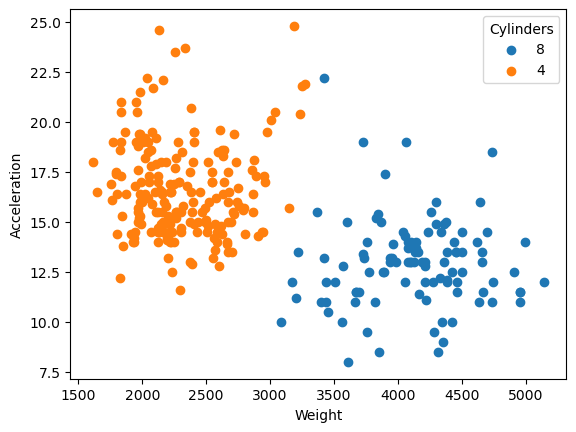

In [111]:
# If we call plt.scatter() twice to display two plots
# To display all plots simultaneously we include plt.show() at the very end.
# The idea is that the graphs are stacked on top of each other

df_8 = carfeatures.query("cylinders == 8")
df_4 = carfeatures.query("cylinders == 4")

plt.scatter(x = df_8["weight"],y = df_8["acceleration"])
plt.scatter(x = df_4["weight"],y = df_4["acceleration"])
plt.legend(labels = ["8","4"],
           title  = "Cylinders")

plt.xlabel("Weight")
plt.ylabel("Acceleration")
plt.show()

# Note: If we put plt.show() in between the plots, then the results will
# be shown on separate graphs instead.

<font size = "4">

Compute plots by all categories

In [ ]:
# Compute number of unique categories
list_unique_cylinders = pd.unique(carfeatures["cylinders"])

# Use a for loop to plot a scatter plot between "weight" and "acceleration"
# for each category. Each plot  will have a different color

for category in list_unique_cylinders:
    df   = carfeatures.query("cylinders == @category")
    plt.scatter(x = df["weight"], y = df["acceleration"])
    
# Add labels and a legends    
plt.xlabel("Weight")
plt.ylabel("Acceleration")
plt.legend(labels = list_unique_cylinders,
           title  = "Cylinders")
plt.show()

<font size="4">

**Exercise:** Compute a histogram of "mpg" by cylinder count for cars with 4, 6, and 8 cylinders.Here is what it might look like (using a fake dataset):

<img src="data_raw/fake_histogram.png" alt="drawing" width="400"/>


You can make the histograms transparent by adjusting ```alpha``` in

```python
    plt.hist(x = ..., alpha = 0.5)
```

In [ ]:
# your code here

